# Fib / ZOI Scan Backtest — Result Analysis

Loads the per-trade ledger produced by `scripts/backtest/run-scan.mjs`
(`data/backtest/trades-*.csv`) and lets you verify every trade by hand.

- **Window:** signals 2019 → 2025 — spans the COVID crash, the 2020-21 bull run, the 2022 correction and the 2023-24 recovery, so every Nifty regime (BULL / BEAR / NEUTRAL) is exercised.
- **Universe:** ~127 stocks, stratified ~10 per sector across 16 sectors, ₹500–3,000 band, picked by a **fixed seed** (`pick-universe.mjs`) then **liquidity-trimmed** (median daily ₹-turnover ≥ ₹2 cr, `liquidity-trim.mjs`) — so the set can't be cherry-picked and deliberately includes laggards (less survivorship bias). The `sector` column lets you slice by industry.
- **Modes:** FIB, ZOI, FIB+ZOI · **TFs:** daily + weekly
- **Engine:** this notebook analyses the **SCAN** ledger (`trades-<date>.csv`, from `run-scan.mjs`). The `generatePlan` deep-engine ledger (`trades-generateplan-<date>.csv`) has a different shape (one `DEEP` mode, no per-TF split) and is analysed separately.
- **Trade model:**
  - **Sizing:** deploy **₹1,00,000 per trade** → `shares = floor(100000 / fill_price)` (fixed notional, single open position per stock×mode×TF).
  - **Entry:** limit-buy at the engine's `planned_entry`, filled if a session low touches it within 3 sessions.
  - **Target (swing):** `planned_entry + 2.0 × (planned_entry − stop_loss)` — i.e. **2R**. The engine's own tight `rrT1` is *not* used (it was a scalper's target, median 0.13R).
  - **Stop:** the engine's `stop_loss` (`rrSl`). **Time-stop:** 30 trading sessions (~6 weeks).
  - **Target reachability (`mfe_R`):** max favourable excursion in R *ignoring* our 2R target but *respecting* the stop — i.e. how far each filled trade actually ran while we were in it. This is the empirical basis for sizing a T1/T2 target (§7).
  - **Faithfulness note:** each as-of slice is capped to the **live app's lookback window** (daily 2y, weekly 3y) before the engine runs, so the backtest verdict is computed on exactly the history the live `scanVerdictFromCandles` sees — not the full harvested series (which would shift the fib/S-R anchors).
  - **Market hours:** every daily bar is a real NSE session (incl. Budget-Saturday / Muhurat / DR-test sessions), so fills/exits are inherently in-session. **Trades carry the trading DATE only** — daily candles have no intraday clock, so there is no execution HH:MM (it isn't recoverable from daily data).
  - **Costs:** 0.05%/side slippage proxy (no brokerage/STT).

Run order: top to bottom. Kernel = the project `.venv`.

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd

BACKTEST_DIR: Path = Path.cwd()
# Notebook may launch from repo root or from scripts/backtest — resolve either way.
for _candidate in (Path.cwd(), Path.cwd() / "data" / "backtest", Path.cwd().parent.parent / "data" / "backtest"):
    if list(_candidate.glob("trades-*.csv")):
        BACKTEST_DIR = _candidate
        break


def latest_trades_csv(directory: Path) -> Path:
    """Return the newest SCAN ledger (trades-<date>.csv) in `directory`.

    Excludes the generatePlan deep-engine ledger (trades-generateplan-<date>.csv),
    which has a different column shape (single DEEP mode, no per-TF split) and is
    analysed in its own notebook section. Scan files are named `trades-YYYY-MM-DD.csv`,
    so the date char right after the prefix is a digit — we key off that.
    """
    files: list[Path] = sorted(
        f for f in directory.glob("trades-*.csv")
        if f.name[len("trades-")].isdigit()  # date-stamped scan ledger only
    )
    if not files:
        raise FileNotFoundError(f"No scan trades-<date>.csv found in {directory.resolve()}")
    return files[-1]


def load_trades(csv_path: Path) -> pd.DataFrame:
    """Load the per-trade ledger with explicit, typed columns.

    Daily data has no intraday clock, so trades carry the trading DATE only —
    there is no fabricated execution time. `hold_trading_bars` / `hold_calendar_days`
    capture duration; the true intra-session minute is unknown by construction.
    """
    date_cols: list[str] = ["signal_date", "entry_date", "exit_date"]
    frame: pd.DataFrame = pd.read_csv(csv_path, parse_dates=date_cols)
    # `sector` was added with the broad-universe run; tolerate older ledgers.
    categoricals: list[str] = ["stock", "timeframe", "mode", "status", "exit_reason", "regime"]
    if "sector" in frame.columns:
        categoricals.append("sector")
    for col in categoricals:
        frame[col] = frame[col].astype("category")
    return frame


CSV_PATH: Path = latest_trades_csv(BACKTEST_DIR)
trades: pd.DataFrame = load_trades(CSV_PATH)
print(f"Loaded {len(trades)} signal rows from {CSV_PATH}")
trades.dtypes

Loaded 12379 signal rows from /Users/saurabh.sharma2/Work/learning/candle-stick-pattern/data/backtest/trades-2026-06-02.csv


stock                       category
isin                             str
sector                      category
timeframe                   category
mode                        category
status                      category
exit_reason                 category
regime                      category
fib_class                        str
zoi_position                     str
signal_date           datetime64[us]
signal_close                 float64
planned_entry                float64
stop_loss                    float64
target                       float64
entry_date            datetime64[us]
entry_fill                   float64
exit_date             datetime64[us]
exit_fill                    float64
shares                       float64
capital_deployed             float64
hold_trading_bars            float64
hold_calendar_days           float64
R_multiple                   float64
mfe_R                        float64
pnl_rupees                   float64
dtype: object

## 1. The full ledger (every signal)

`status` is one of `WIN` / `LOSS` (resolved), `NO_FILL` (limit never touched), `OPEN`
(still running at window end). Scroll right for entry/exit fills, hold time, R and ₹P&L.

In [2]:
pd.set_option("display.max_rows", 250)
pd.set_option("display.max_columns", None)   # show every column
pd.set_option("display.width", None)         # don't wrap on terminal width
pd.set_option("display.max_colwidth", None)  # don't truncate cell text
pd.set_option("display.expand_frame_repr", False)  # keep all columns on one row block

# Show all resolved trades first (the ones with real P&L), newest signal last.
resolved: pd.DataFrame = trades[trades["status"].isin(["WIN", "LOSS"])].copy()
resolved = resolved.sort_values(["stock", "timeframe", "mode", "signal_date"]).reset_index(drop=True)
resolved

,stock,isin,sector,timeframe,mode,status,exit_reason,regime,fib_class,zoi_position,signal_date,signal_close,planned_entry,stop_loss,target,entry_date,entry_fill,exit_date,exit_fill,shares,capital_deployed,hold_trading_bars,hold_calendar_days,R_multiple,mfe_R,pnl_rupees
0,63MOONS,INE111B01023,it,1d,FIB,LOSS,SL,BULL,IN_POCKET_UP,NaN,2024-01-12,453.30,453.30,430.64,498.65,2024-01-15,445.82,2024-01-18,430.43,224.0,99864.0,4.0,3.0,-1.01,1.07,-3447.0
1,63MOONS,INE111B01023,it,1d,FIB,LOSS,SL,BULL,IN_POCKET_UP,NaN,2024-05-17,409.15,409.15,395.37,436.70,2024-05-18,405.20,2024-05-27,378.06,246.0,99680.0,6.0,9.0,-2.76,3.06,-6677.0
2,63MOONS,INE111B01023,it,1d,FIB,WIN,TARGET,BEAR,IN_POCKET_UP,NaN,2024-11-21,577.85,577.85,548.96,635.65,2024-11-22,578.14,2024-11-29,643.68,172.0,99440.0,6.0,7.0,2.25,17.16,11273.0
3,63MOONS,INE111B01023,it,1d,FIB,LOSS,SL,NEUTRAL,IN_POCKET_UP,NaN,2025-04-16,741.10,741.10,704.05,815.20,2025-04-17,727.41,2025-04-24,703.70,137.0,99656.0,5.0,7.0,-1.01,1.09,-3249.0
4,63MOONS,INE111B01023,it,1d,FIB,LOSS,SL,BULL,IN_POCKET_UP,NaN,2025-07-22,1075.00,1075.00,1021.25,1182.50,2025-07-23,1075.54,2025-07-28,1020.74,92.0,98949.0,4.0,5.0,-1.01,0.67,-5041.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11213,VTL,INE825A01020,textiles,1w,FIB_ZOI,LOSS,SL,NEUTRAL,IN_POCKET_UP,NEAR_BELOW_SUPPLY,2025-04-01,470.75,470.75,435.71,540.80,2025-04-08,462.68,2025-04-09,435.48,216.0,99939.0,2.0,1.0,-1.01,0.41,-5875.0
11214,VTL,INE825A01020,textiles,1w,FIB_ZOI,WIN,TARGET,BULL,IN_POCKET_UP,NEAR_BELOW_SUPPLY,2025-04-21,464.70,464.70,441.47,511.15,2025-04-28,458.23,2025-05-19,510.89,218.0,99894.0,15.0,21.0,3.14,4.28,11481.0
11215,VTL,INE825A01020,textiles,1w,ZOI,LOSS,TIME,BULL,NaN,FAR_ABOVE_DEMAND,2021-10-11,406.60,406.60,217.89,784.00,2021-10-18,406.80,2021-11-30,406.20,245.0,99667.0,30.0,43.0,0.00,0.14,-149.0
11216,VTL,INE825A01020,textiles,1w,ZOI,WIN,TIME,BEAR,NaN,FAR_ABOVE_DEMAND,2021-12-13,447.25,447.25,215.85,910.05,2021-12-20,447.47,2022-01-31,480.56,223.0,99787.0,30.0,42.0,0.14,0.55,7378.0


## 2. Summary by stock × timeframe × mode

Win rate, net ₹ P&L (₹1,00,000 deployed per trade), total R, and average hold. This is the table
the text report printed — recomputed here so you can audit the math.

In [3]:
def summarize(group: pd.DataFrame) -> pd.Series:
    """Pure per-group aggregation — win rate, P&L, R, hold."""
    n: int = len(group)
    wins: int = int((group["status"] == "WIN").sum())
    return pd.Series(
        {
            "trades": n,
            "win_%": round(100.0 * wins / n, 1) if n else 0.0,
            "net_pnl": int(group["pnl_rupees"].sum()),
            "avg_pnl": round(group["pnl_rupees"].mean(), 1) if n else 0.0,
            "sum_R": round(group["R_multiple"].sum(), 2),
            "avg_R": round(group["R_multiple"].mean(), 2) if n else 0.0,
            "avg_hold_bars": round(group["hold_trading_bars"].mean(), 1) if n else 0.0,
            "avg_hold_days": round(group["hold_calendar_days"].mean(), 1) if n else 0.0,
            "avg_shares": int(group["shares"].mean()) if n else 0,
        }
    )


by_group: pd.DataFrame = (
    resolved.groupby(["stock", "timeframe", "mode"], observed=True)
    .apply(summarize, include_groups=False)
    .reset_index()
)
by_group

,stock,timeframe,mode,trades,win_%,net_pnl,avg_pnl,sum_R,avg_R,avg_hold_bars,avg_hold_days,avg_shares
0,63MOONS,1d,FIB,8.0,25.0,-6592.0,-824.0,-3.59,-0.45,5.1,5.9,155.0
1,63MOONS,1d,FIB_ZOI,11.0,18.2,-5048.0,-458.9,-5.00,-0.45,20.1,28.3,155.0
2,63MOONS,1d,ZOI,12.0,33.3,24092.0,2007.7,-0.56,-0.05,20.2,27.6,150.0
3,63MOONS,1w,FIB_ZOI,5.0,60.0,51765.0,10353.0,2.57,0.51,29.8,41.0,186.0
4,63MOONS,1w,ZOI,9.0,55.6,59621.0,6624.6,1.91,0.21,30.0,41.7,168.0
...,...,...,...,...,...,...,...,...,...,...,...,...
719,VTL,1d,FIB_ZOI,18.0,38.9,-38477.0,-2137.6,-2.70,-0.15,25.8,36.0,217.0
720,VTL,1d,ZOI,22.0,31.8,-101186.0,-4599.4,-9.43,-0.43,17.9,25.1,216.0
721,VTL,1w,FIB,3.0,33.3,-1812.0,-604.0,1.12,0.37,10.0,13.3,215.0
722,VTL,1w,FIB_ZOI,4.0,25.0,-13955.0,-3488.8,0.52,0.13,15.0,20.8,211.0


## 3. The payoff-geometry problem (planned reward:risk)

`planned_rr = (target − entry) / (entry − stop_loss)`. If most signals start below
1.0, the strategy is structurally "win small / lose big" no matter how high the hit-rate.

In [4]:
def planned_rr(row: pd.Series) -> float:
    """Planned reward:risk from entry/SL/target (NaN if degenerate)."""
    risk: float = row["planned_entry"] - row["stop_loss"]
    reward: float = row["target"] - row["planned_entry"]
    return reward / risk if risk > 0 else float("nan")


resolved = resolved.assign(planned_rr=resolved.apply(planned_rr, axis=1).round(2))

sub_1r: int = int((resolved["planned_rr"] < 1.0).sum())
print(f"Resolved trades: {len(resolved)}")
print(f"  planned R:R < 1.0 : {sub_1r}  ({100 * sub_1r / len(resolved):.0f}%)")
print(f"  median planned R:R: {resolved['planned_rr'].median():.2f}")
print(f"  win-rate          : {100 * (resolved['status'] == 'WIN').mean():.0f}%")
print(f"  net P&L (all)     : ₹{int(resolved['pnl_rupees'].sum()):,}")

resolved["planned_rr"].describe().round(2)

Resolved trades: 11218
  planned R:R < 1.0 : 0  (0%)
  median planned R:R: 2.00
  win-rate          : 47%
  net P&L (all)     : ₹14,879,109


count    11218.0
mean         2.0
std          0.0
min          2.0
25%          2.0
50%          2.0
75%          2.0
max          2.0
Name: planned_rr, dtype: float64

## 4. Cumulative P&L curve (signal-quality aggregate)

Trades ordered by exit date, P&L accumulated across **all** stocks/modes/TFs (₹1,00,000 per trade).

> ⚠️ This is a **signal-quality aggregate, not a tradeable account curve** — across ~127 stocks × 3 modes × 2 TFs the tracks overlap heavily in time (you could never hold hundreds of ₹1 L positions at once). Read it as "does the edge compound positively over the full cycle?", not as a realisable equity path. The §6 per-regime / per-mode rollups are the decision-grade numbers.

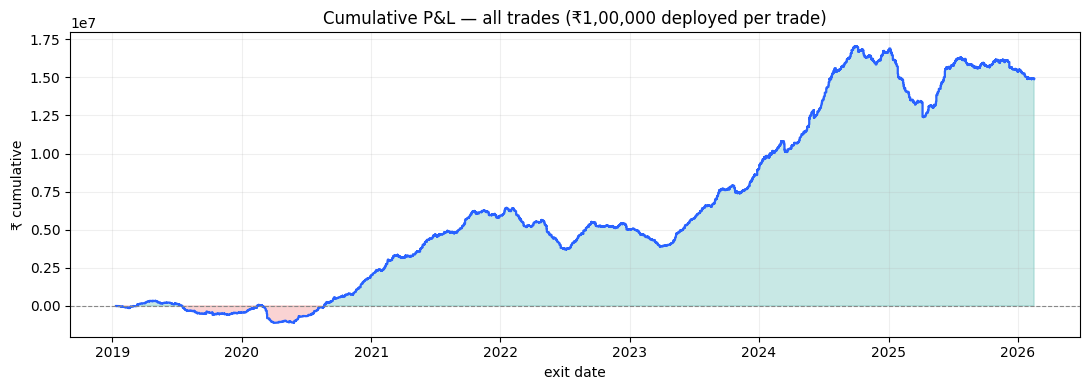

In [5]:
import matplotlib.pyplot as plt

curve: pd.DataFrame = resolved.sort_values("exit_date").copy()
curve["cum_pnl"] = curve["pnl_rupees"].cumsum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(curve["exit_date"], curve["cum_pnl"], linewidth=1.6, color="#2962ff")
ax.axhline(0, color="#888", linewidth=0.8, linestyle="--")
ax.fill_between(curve["exit_date"], curve["cum_pnl"], 0,
                where=curve["cum_pnl"] >= 0, color="#26a69a", alpha=0.25)
ax.fill_between(curve["exit_date"], curve["cum_pnl"], 0,
                where=curve["cum_pnl"] < 0, color="#ef5350", alpha=0.25)
ax.set_title("Cumulative P&L — all trades (₹1,00,000 deployed per trade)")
ax.set_ylabel("₹ cumulative")
ax.set_xlabel("exit date")
ax.grid(True, alpha=0.2)
fig.tight_layout()
plt.show()

## 5. Signal disposition & portfolio totals

Every signal the engine fired, by outcome — including the ones that never filled
(`NO_FILL`) or were still running at the window end (`OPEN`), so nothing is hidden.

In [6]:
disposition: pd.Series = trades["status"].value_counts()
print("Signal disposition (all", len(trades), "signals):")
print(disposition.to_string())

net: int = int(resolved["pnl_rupees"].sum())
gross_win: int = int(resolved.loc[resolved["status"] == "WIN", "pnl_rupees"].sum())
gross_loss: int = int(resolved.loc[resolved["status"] == "LOSS", "pnl_rupees"].sum())
profit_factor: float = gross_win / abs(gross_loss) if gross_loss else float("inf")
exp_r: float = resolved["R_multiple"].mean()

print("\nPortfolio (resolved trades only):")
print(f"  trades taken    : {len(resolved)}")
print(f"  win rate        : {100 * (resolved['status'] == 'WIN').mean():.1f}%")
print(f"  net P&L         : ₹{net:,}")
print(f"  gross win/loss  : ₹{gross_win:,} / ₹{gross_loss:,}")
print(f"  profit factor   : {profit_factor:.2f}")
print(f"  expectancy/trade: {exp_r:.2f} R  (₹{int(resolved['pnl_rupees'].mean()):,})")
print(f"  avg hold        : {resolved['hold_trading_bars'].mean():.1f} sessions"
      f" ({resolved['hold_calendar_days'].mean():.1f} calendar days)")

# Best / worst stock × mode × TF buckets by net P&L.
print("\nMost profitable buckets:")
print(by_group.sort_values("net_pnl", ascending=False).head(5).to_string(index=False))
print("\nLeast profitable buckets:")
print(by_group.sort_values("net_pnl").head(5).to_string(index=False))

Signal disposition (all 12379 signals):
status
LOSS       5991
WIN        5227
NO_FILL    1161

Portfolio (resolved trades only):
  trades taken    : 11218
  win rate        : 46.6%
  net P&L         : ₹14,879,109
  gross win/loss  : ₹55,825,296 / ₹-40,946,187
  profit factor   : 1.36
  expectancy/trade: 0.09 R  (₹1,326)
  avg hold        : 20.9 sessions (29.2 calendar days)

Most profitable buckets:
    stock timeframe    mode  trades  win_%  net_pnl  avg_pnl  sum_R  avg_R  avg_hold_bars  avg_hold_days  avg_shares
DALBHARAT        1d FIB_ZOI    35.0   65.7 193052.0   5515.8  17.40   0.50           21.7           30.4        74.0
     GRSE        1d     ZOI    18.0   66.7 177761.0   9875.6   7.18   0.40           20.9           29.9       112.0
DEEPAKNTR        1d     ZOI    27.0   70.4 168617.0   6245.1  15.98   0.59           23.1           33.0        84.0
  ESCORTS        1d     ZOI    32.0   62.5 164239.0   5132.5  18.53   0.58           21.8           30.7        91.0
     GRSE  

## 6. Rollups — the decision-grade tables

The §2 table is per *stock × TF × mode* (hundreds of rows — useful for drill-down, too granular to judge the engine). These rollups aggregate across the whole universe so you can see **where the edge actually lives**: which mode, which timeframe, and — critically — which **market regime**. Expectancy (`avg_R`) is the number that matters: positive = the edge survives costs; the win-% alone can lie if losers are bigger than winners.

In [7]:
def rollup(df: pd.DataFrame, by: list[str]) -> pd.DataFrame:
    """Aggregate `summarize` over the given grouping, sorted by net P&L."""
    out: pd.DataFrame = (
        df.groupby(by, observed=True)
        .apply(summarize, include_groups=False)
        .reset_index()
        .sort_values("net_pnl", ascending=False)
        .reset_index(drop=True)
    )
    return out


print("── by MODE × TIMEFRAME ──")
display(rollup(resolved, ["mode", "timeframe"]))

print("── by MODE (both TFs) ──")
display(rollup(resolved, ["mode"]))

# Regime in calendar order (not P&L) so the cycle reads naturally.
print("── by NIFTY REGIME (all modes) ──")
_reg = rollup(resolved, ["regime"]).set_index("regime")
display(_reg.reindex([r for r in ["BULL", "NEUTRAL", "BEAR"] if r in _reg.index]))

if "sector" in resolved.columns:
    print("── by SECTOR (all modes) ──")
    display(rollup(resolved, ["sector"]))

── by MODE × TIMEFRAME ──


,mode,timeframe,trades,win_%,net_pnl,avg_pnl,sum_R,avg_R,avg_hold_bars,avg_hold_days,avg_shares
0,ZOI,1d,3185.0,47.8,4354081.0,1367.1,362.01,0.11,21.5,30.1,133.0
1,ZOI,1w,1704.0,54.3,3923889.0,2302.8,173.31,0.10,28.2,39.5,131.0
2,FIB_ZOI,1d,3007.0,46.9,3792755.0,1261.3,277.08,0.09,21.4,30.1,133.0
3,FIB_ZOI,1w,1259.0,51.0,2557834.0,2031.6,101.96,0.08,25.9,36.1,132.0
4,FIB,1d,1621.0,35.8,376745.0,232.4,93.31,0.06,10.1,13.5,133.0
5,FIB,1w,442.0,33.0,-126195.0,-285.5,-40.20,-0.09,11.8,15.3,136.0


── by MODE (both TFs) ──


,mode,trades,win_%,net_pnl,avg_pnl,sum_R,avg_R,avg_hold_bars,avg_hold_days,avg_shares
0,ZOI,4889.0,50.1,8277970.0,1693.2,535.32,0.11,23.8,33.4,132.0
1,FIB_ZOI,4266.0,48.1,6350589.0,1488.7,379.04,0.09,22.7,31.9,133.0
2,FIB,2063.0,35.2,250550.0,121.4,53.11,0.03,10.5,13.9,134.0


── by NIFTY REGIME (all modes) ──


,trades,win_%,net_pnl,avg_pnl,sum_R,avg_R,avg_hold_bars,avg_hold_days,avg_shares
regime,,,,,,,,,
BULL,6670.0,48.7,13636179.0,2044.4,795.96,0.12,22.0,30.6,133.0
NEUTRAL,1708.0,44.9,721291.0,422.3,144.55,0.08,20.5,28.9,134.0
BEAR,2840.0,42.8,521639.0,183.7,26.96,0.01,18.7,26.3,132.0


── by SECTOR (all modes) ──


,sector,trades,win_%,net_pnl,avg_pnl,sum_R,avg_R,avg_hold_bars,avg_hold_days,avg_shares
0,telecom-infra,1080.0,52.1,1979347.0,1832.7,173.43,0.16,21.5,30.0,119.0
1,banking,989.0,52.7,1458869.0,1475.1,119.99,0.12,22.4,31.3,142.0
2,industrial-goods,629.0,45.0,1311179.0,2084.5,26.02,0.04,20.8,29.2,115.0
3,financial-services,872.0,48.6,1298774.0,1489.4,120.76,0.14,20.8,29.0,141.0
4,oil-gas,856.0,42.8,1290120.0,1507.1,56.89,0.07,20.4,28.4,115.0
5,metals,596.0,50.8,1241488.0,2083.0,100.85,0.17,21.7,30.4,122.0
6,cement-construction,670.0,47.8,1188203.0,1773.4,53.83,0.08,21.2,29.7,131.0
7,fmcg-consumer,1169.0,48.0,1130587.0,967.1,138.78,0.12,21.6,30.2,126.0
8,auto,846.0,45.2,1120509.0,1324.5,75.64,0.09,20.9,29.1,143.0
9,it,537.0,48.8,1071255.0,1994.9,75.26,0.14,20.0,27.8,115.0


## 7. Target reachability — how far do trades actually run?

`mfe_R` = maximum favourable excursion in R, **ignoring our 2R target but respecting the stop** (i.e. how far each *filled* trade ran before it either stopped out or hit the 30-session horizon). This is the honest, exit-rule-independent answer to *"how aggressive can the target be?"*

Read the curve as: **of every trade we entered, what share ran at least N·risk in our favour at some point?** If only, say, 16% ever reach 2R, then a fixed 2R target caps the hit-rate near 16% — you'd capture more by taking partials at 1R (where ~38% reach) and trailing the rest. This is the empirical input for a T1 / T2 ladder.

Target reachability over 11218 filled trades:


,all_share_%,all_n
reach_>=_R,,
0.5,56.5,6341
1.0,34.7,3898
1.5,23.1,2587
2.0,16.3,1832
2.5,12.1,1359
3.0,9.2,1034
4.0,5.9,661



Reachability by mode (share %):


,FIB_share_%,FIB_ZOI_share_%,ZOI_share_%
reach_>=_R,,,
0.5,69.0,52.5,54.8
1.0,51.1,30.7,31.4
1.5,39.6,19.4,19.3
2.0,31.4,13.6,12.4
2.5,25.2,9.8,8.6
3.0,20.8,7.5,5.8
4.0,14.5,4.5,3.4


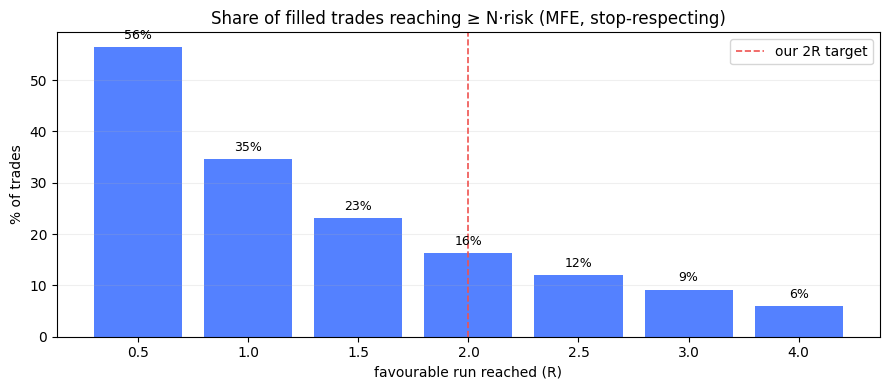

In [8]:
import numpy as np

LEVELS: list[float] = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0]

filled: pd.DataFrame = resolved[resolved["mfe_R"].notna()].copy()


def reach_table(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Share of trades whose favourable run reached ≥ each R level."""
    n: int = len(df)
    return pd.DataFrame({
        "reach_>=_R": LEVELS,
        f"{label}_share_%": [round(100.0 * (df["mfe_R"] >= r).mean(), 1) if n else 0.0 for r in LEVELS],
        f"{label}_n": [int((df["mfe_R"] >= r).sum()) for r in LEVELS],
    }).set_index("reach_>=_R")


overall: pd.DataFrame = reach_table(filled, "all")
print(f"Target reachability over {len(filled)} filled trades:")
display(overall)

# Per-mode reachability — ZOI vs FIB often have very different "legs".
per_mode = pd.concat(
    [reach_table(filled[filled["mode"] == m], m)[[f"{m}_share_%"]] for m in filled["mode"].cat.categories
     if (filled["mode"] == m).any()],
    axis=1,
)
print("\nReachability by mode (share %):")
display(per_mode)

# Plot the overall curve, marking our 2R target.
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([str(r) for r in LEVELS], overall["all_share_%"], color="#2962ff", alpha=0.8)
ax.axvline(LEVELS.index(2.0), color="#ef5350", linestyle="--", linewidth=1.2, label="our 2R target")
for i, r in enumerate(LEVELS):
    ax.text(i, overall["all_share_%"].iloc[i] + 1, f"{overall['all_share_%'].iloc[i]:.0f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_title("Share of filled trades reaching ≥ N·risk (MFE, stop-respecting)")
ax.set_ylabel("% of trades")
ax.set_xlabel("favourable run reached (R)")
ax.legend()
ax.grid(True, axis="y", alpha=0.2)
fig.tight_layout()
plt.show()